In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision.transforms as transforms
from torch.utils.data import DataLoader, Dataset
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm import tqdm
from easydict import EasyDict as edict

class FashionMNISTDataset(Dataset):
    def __init__(self, csv_file, transform=None):
        self.data = pd.read_csv(csv_file)
        self.transform = transform or transforms.Compose([
            transforms.ToPILImage(),
            transforms.Resize((32, 32)),  
            transforms.ToTensor()
        ])

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        row = self.data.iloc[idx].values
        label = int(row[0])
        image = row[1:].astype(np.uint8).reshape(28, 28) 
        image = np.expand_dims(image, axis=2)  
        image = self.transform(image)

        return image, image, label 

class EncoderVAE(nn.Module):
    def __init__(self):
        super(EncoderVAE, self).__init__()

        # inputan 1 x 32 x 32 > 32 x 16 x 16
        self.conv1 = nn.Conv2d(1, 32, kernel_size=3, stride=2, padding=1) 
        
        # inputan 32 x 16 x 16 > 64 x 8 x 8
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, stride=2, padding=1)

        # inputan 64 x 8 x 8 > 128 x 4 x 4
        self.conv3 = nn.Conv2d(64, 128, kernel_size=3, stride=2, padding=1)

        self.relu = nn.ReLU()

        self.flatten = nn.Flatten()

        self.fc_mu = nn.Linear(128 * 4 * 4, 2)
        self.fc_logvar = nn.Linear(128 * 4 * 4, 2)

    def _reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + std * eps

    def forward(self, x):
        x = self.relu(self.conv1(x))
        x = self.relu(self.conv2(x))
        x = self.relu(self.conv3(x))

        x = self.flatten(x)

        mu = self.fc_mu(x)
        logvar = self.fc_logvar(x)
        z = self._reparameterize(mu, logvar)

        return z, mu, logvar


class Encoder(nn.Module):
    def __init__(self):
        super(Encoder, self).__init__()
        self.encoder = nn.Sequential(
            nn.Conv2d(1, 32, kernel_size=3, stride=2, padding=1),  # 16x16
            nn.ReLU(),
            nn.Conv2d(32, 64, kernel_size=3, stride=2, padding=1), # 8x8
            nn.ReLU(),
            nn.Conv2d(64, 128, kernel_size=3, stride=2, padding=1),# 4x4
            nn.ReLU(),
            nn.Flatten(),                                          # 2048
            nn.Linear(2048, 2)                                     # bottleneck
        )

    def forward(self, x):
        return self.encoder(x)

class Decoder(nn.Module):
    def __init__(self):
        super(Decoder, self).__init__()
        self.decoder = nn.Sequential(
            nn.Linear(2, 2048),
            nn.Unflatten(1, (128, 4, 4)),
            nn.ConvTranspose2d(128, 128, kernel_size=3, stride=2, padding=1, output_padding=1),
            nn.ReLU(),
            nn.ConvTranspose2d(128, 64, kernel_size=3, stride=2, padding=1, output_padding=1),
            nn.ReLU(),
            nn.ConvTranspose2d(64, 32, kernel_size=3, stride=2, padding=1, output_padding=1),
            nn.ReLU(),
            nn.Conv2d(32, 1, kernel_size=3, padding=1),
            nn.Sigmoid()
        )

    def forward(self, x):
        return self.decoder(x)

class Autoencoder(nn.Module):
    def __init__(self):
        super(Autoencoder, self).__init__()
        self.encoder = Encoder()
        self.decoder = Decoder()

    def forward(self, x):
        z = self.encoder(x)
        out = self.decoder(z)
        return out

class VAE(nn.Module):
    def __init__(self):
        super(VAE, self).__init__()
        self.encoder = EncoderVAE()
        self.decoder = Decoder()

    def forward(self, x):
        z, mu, logvar = self.encoder(x)
        out = self.decoder(z)
        return out, mu, logvar


def vae_loss(recon_x, x, mu, logvar, beta=1.0):
    recon_loss = nn.functional.binary_cross_entropy(recon_x, x, reduction='sum')
    kl_loss = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp())
    return recon_loss  + beta * kl_loss, recon_loss, kl_loss

# Entry Point

In [2]:
def main(args):
    # Datasets
    train_dataset = FashionMNISTDataset('/kaggle/input/datasets/organizations/zalando-research/fashionmnist/fashion-mnist_train.csv')
    test_dataset = FashionMNISTDataset('/kaggle/input/datasets/organizations/zalando-research/fashionmnist/fashion-mnist_test.csv')
    
    train_loader = DataLoader(train_dataset, batch_size=128, shuffle=True)
    
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    
    if args.model_name == 'AE':
        model = Autoencoder().to(device)
    elif args.model_name == 'VAE':
        model = VAE().to(device)
    
    criterion = nn.MSELoss()
    optimizer = optim.Adam(model.parameters(), lr=1e-3)
    
    epochs = args.epochs
    
    train_loss, recon_losses, kl_losses = [], [], []
    for epoch in range(epochs):
        total_loss = 0
        total_recon = 0
        total_kl = 0
        for imgs, _, _ in tqdm(train_loader, desc=f"Epoch {epoch+1}"):
            imgs = imgs.to(device)
            
            if args.model_name == 'AE':
                outputs = model(imgs)
                loss = criterion(outputs, imgs)
                optimizer.zero_grad()
                loss.backward()
                optimizer.step()
    
                total_loss += loss.item()
            elif args.model_name == 'VAE':
                recon, mu, logvar = model(imgs)
                loss, recon_loss, kl_loss = vae_loss(recon, imgs, mu, logvar)
                
                optimizer.zero_grad()
                loss.backward()
                optimizer.step()
    
                total_loss += loss.item()
                total_recon += recon_loss.item()
                total_kl += kl_loss.item()
    
        train_loss.append(total_loss / len(train_loader))
        
        recon_losses.append(total_recon / len(train_loader))
        kl_losses.append(total_kl / len(train_loader))
        
        print(f"Epoch [{epoch+1}/{epochs}], Loss: {total_loss/len(train_loader):.4f}")
    
    torch.save(model.state_dict(), 'model_'+args.model_name+'.pth')

In [3]:
# Entry Point
args = edict(
    {
        "lr": 1e-3,
        "batch_size": 128,
        "epochs": 10,
        "model_name": "VAE"
    }
)

main(args)

Epoch 1: 100%|██████████| 469/469 [00:22<00:00, 20.91it/s]


Epoch [1/10], Loss: 50285.1550


Epoch 2: 100%|██████████| 469/469 [00:21<00:00, 22.21it/s]


Epoch [2/10], Loss: 45645.0247


Epoch 3: 100%|██████████| 469/469 [00:21<00:00, 22.21it/s]


...

Epoch [8/10], Loss: 44482.2654


Epoch 9: 100%|██████████| 469/469 [00:20<00:00, 22.33it/s]


Epoch [9/10], Loss: 44411.3197


Epoch 10: 100%|██████████| 469/469 [00:20<00:00, 22.38it/s]

Epoch [10/10], Loss: 44347.4866


# Reconstruction

In [4]:
def show_reconstruction(args):
    train_dataset = FashionMNISTDataset('/kaggle/input/datasets/organizations/zalando-research/fashionmnist/fashion-mnist_train.csv')

    train_loader = DataLoader(train_dataset, batch_size=128, shuffle=True)

    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    
    if args.model_name == 'AE':
        model = Autoencoder().to(device)
    elif args.model_name == 'VAE':    
        model = VAE().to(device)
    
    model.load_state_dict(torch.load("model_"+args.model_name+".pth", map_location=device, weights_only=True))
    model.eval()
    with torch.no_grad():
        test_imgs, _,_ = next(iter(train_loader))
        test_imgs = test_imgs.to(device)

        if args.model_name == 'AE':
            outputs = model(test_imgs)
        elif args.model_name == 'VAE':
            outputs, _, _ = model(test_imgs)

        # Show original and reconstructed
        n = 10
        plt.figure(figsize=(20, 4))
        for i in tqdm(range(n),desc="showing reconstruction"):
            # original
            ax = plt.subplot(2, n, i + 1)
            plt.imshow(test_imgs[i].cpu().squeeze(), cmap='gray')
            ax.axis("off")
            
            # reconstructed
            ax = plt.subplot(2, n, i + 1 + n)
            plt.imshow(outputs[i].cpu().squeeze(), cmap='gray')
            ax.axis("off")
        plt.show()

showing reconstruction: 100%|██████████| 10/10 [00:00<00:00, 75.45it/s]


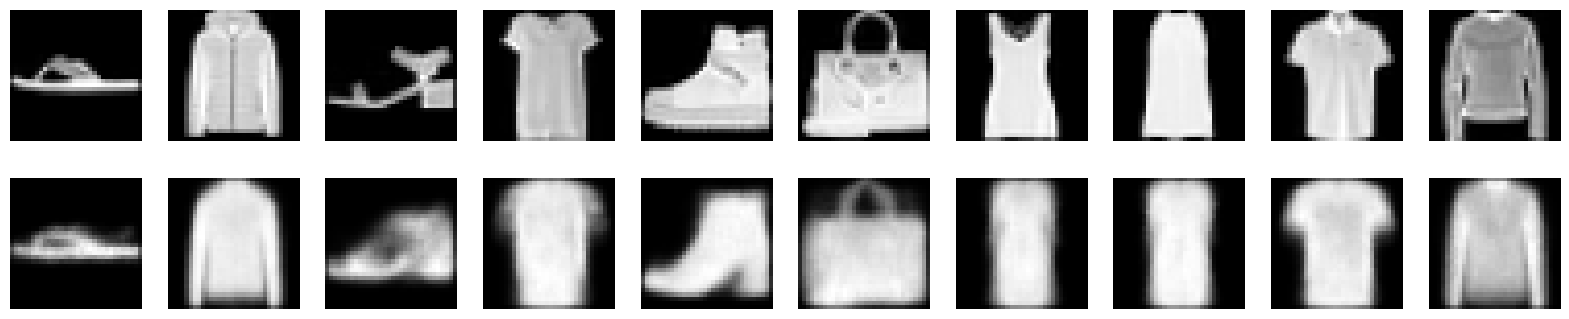

In [5]:
show_reconstruction(args)